In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyampute.exploration.mcar_statistical_tests import MCARTest
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

# Bước 1: Split data
- Split dữ liệu theo khoảng thời gian, từ quá khứ -> tương lai để tránh leak phân phối trong tương lai.
- Sau khi thực hiện split data sẽ tiến hành giải quyết bài toán theo pipeline như sau:
    - EDA cho dữ liệu thô: tương quan, biến đổi. (file này)
    - Fill missing value, đảm bảo dữ liệu đầy đủ. (file này)
    - Shift dữ liệu từ bên dưới lên 1 dòng để tạo target column. (file main)
    - EDA lần 2 cho feature to target. (file main)
    - Tiền xử lý với các bước giải quyết outlier, scale, feature engineering. (file main)
    - Huấn luyện mô hình. (file main)
    - Kiểm thử và nhận xét lỗi. (file main)

## Load và thông tin tổng quát dữ liệu

Dữ liệu hiện tại đã được thu thập từ 2 nguồn khác nhau:
- Mực nước hồ thủy điện: cung cấp bởi tập đoàn điện lực Việt Nam EVN. Dữ liệu này được đo đạc bằng các thiết bị đo chuẩn mực của nhà nước và luôn đảm bảo tính đúng dắn.
- Dữ liệu thời tiết: thu thập sử dụng API của Open Meteo trong các khu vực xung quanh thượng lưu của mỗi hồ thủy điện. Sau khi thu thập tại từng khu vực, tiến hành tính toán trung bình trên mỗi giá trị và xem như đây là dữ liệu thời tiết liên quan đến hồ thủy điện.

In [2]:
# Load
evn = pd.read_csv(r"Data/Raw/evn_SongTranh2_2022_2025.csv")
weather = pd.read_csv(r"Data/Raw/st2_weather_data.csv")

# Info
print("================= EVN =================")
print(evn.info())
print("================= WEATHER =================")
print(weather.info())

================= EVN =================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34947 entries, 0 to 34946
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ten_ho    34947 non-null  object 
 1   ngay      34947 non-null  object 
 2   gio       34947 non-null  object 
 3   H_tl      34947 non-null  float64
 4   H_dbt     34947 non-null  float64
 5   H_c       34947 non-null  float64
 6   Q_ve      34947 non-null  float64
 7   Sigma_Qx  34947 non-null  float64
 8   Q_xt      34947 non-null  float64
 9   Q_xm      34947 non-null  float64
 10  N_cxs     34947 non-null  float64
 11  N_cxm     34947 non-null  float64
dtypes: float64(9), object(3)
memory usage: 3.2+ MB
None
================= WEATHER =================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       ----

In [3]:
evn.head()

,ten_ho,ngay,gio,H_tl,H_dbt,H_c,Q_ve,Sigma_Qx,Q_xt,Q_xm,N_cxs,N_cxm
0,Sông Tranh 2,2022-01-01,00:00,175.0,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0
1,Sông Tranh 2,2022-01-01,01:00,175.0,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0
2,Sông Tranh 2,2022-01-01,02:00,175.0,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0
3,Sông Tranh 2,2022-01-01,03:00,175.0,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0
4,Sông Tranh 2,2022-01-01,04:00,175.0,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0


In [4]:
weather.head()

,Time,Temperature (°C),Humidity (%),Precipitations (mm),Wind_speeds (km/h),Wind_direction (°),Cloud_cover_mid (%),Pressure (hPa),Soil_moisture_0_7cm (m³/m³)
0,2022-01-01T00:00,15.55,95.25,0.12,5.30,177.25,5.50,1023.02,0.5
1,2022-01-01T01:00,15.60,95.50,0.10,5.65,185.75,17.25,1022.48,0.5
2,2022-01-01T02:00,15.55,95.75,0.12,5.73,186.25,9.25,1021.62,0.5
3,2022-01-01T03:00,15.53,96.50,0.03,5.85,177.25,11.00,1020.67,0.5
4,2022-01-01T04:00,15.57,97.25,0.15,5.70,166.25,29.00,1020.40,0.5


- Do khoảng thời gian thu thập là từ 01/01/2022 - 31/12/2025, với bước nhảy là 1 giờ, tức là cần có 35064 dòng dữ liệu.  
- Ta thấy dữ liệu về thời tiết được thu thập đầy đủ, không có missing data, không cần xử lý thêm.
- Dữ liệu về điện lực có missing data ở 1 số thời điểm với số lượng missing ở mỗi biến là như nhau. Cần kiểm tra các biến này có phải là missing đồng thời hay không, có chủ đích hay không, và tìm cách điền khuyết các giá trị này.

**Các biến điện lực** 
- ten_ho: tên hồ thủy điện - dùng để phân biệt các hồ thủy điện.
- ngay: ngày quan sát.
- gio: giờ quan sát.
- H_tl: mực nước thượng lưu tức mực nước hiện tại của hồ chứa.
- H_dbt: mực nước dâng bình thường tức là mực nước tối đa của hồ trong điều kiện bình thường.
- H_c: mực nước chết tức là mực nước thấp nhất mà hồ còn có thể hoạt động.
- Q_ve: lưu lượng nước đến hồ (m3/s), là lượng nước chảy vào hồ.
- Sigma_Qx: tổng lượng xả (m3/s), tính bằng Q_xt + Q_xm.
- Q_xt: tổng lượng xả qua đập tràn (m3/s), thường dùng để xả lũ.
- Q_xm: tổng lượng xả qua nhà máy (m3/s), thường dùng để tạo điện năng.
- N_cxs: số cửa xả sâu đang mở, xả mạnh hơn.
- N_cxm: số cửa xả mặt (nằm gần mặt hồ), mức xả nhẹ hơn.

**Các biến thời tiết**
- Time: thời điểm quan sát gồm ngày, giờ.
- Temperature (°C): nhiệt độ 
- Humidity (%): độ ẩm không khí tức lượng hơi nước trong không khí
- Precipitations (mm): Lượng nước rơi xuống từ khí quyển trong một khoảng thời gian (thường là mưa).
- Wind_speeds (km/h): tốc độ gió.     
- Wind_direction (°): hướng gió: Bắc(0), Nam(180), Đông(90), Tây(270)
- Cloud_cover_mid (%): độ che phủ của mây ở tầng trung lưu         
- Pressure (hPa): áp suất không khí          
- Soil_moisture_0_7cm (m³/m³): độ ẩm đất ở độ sâu 0-7 cm  

## Merge dữ liệu

In [5]:
# Ghép các cột ngày và giờ của dữ liệu evn để tạo biến time làm khóa để merge với weather
def add_time_column(df, date_col="ngay", time_col="gio", new_col="time"):
    df = df.copy()

    df[new_col] = pd.to_datetime(
        df[date_col].astype(str) + " " + df[time_col].astype(str),
        format="%Y-%m-%d %H:%M",
        errors="coerce"
    )
    
    # Di chuyển lên đầu
    cols = [new_col] + [col for col in df.columns if col != new_col]
    df = df[cols]
    
    df = df.drop(columns=["ngay", "gio"])
    return df

# Chuẩn hóa cột time của weather để giống với cột time của evn -> thống nhất format time
def convert_time(df, new_col = "time", old_col = "Time"):
    df[new_col] = pd.to_datetime(
        df[old_col],
        format="%Y-%m-%dT%H:%M",
        errors="coerce"
    )
    cols = [new_col] + [col for col in df.columns if col != new_col]
    df = df[cols]
    df = df.drop(columns=[old_col])
    return df

# Rename các cột bỏ phần đơn vị phía sau
def clean_column_names(df):
    new_columns = {}
    for col in df.columns:
        # Tách lấy phần trước dấu khoảng trắng đầu tiên
        new_name = col.split(' ')[0].lower()
        new_columns[col] = new_name
    
    df.rename(columns=new_columns, inplace=True)
    return df

# Merge 2 bảng theo kiểu outer join thông qua biến time
def merge(df1, df2, _how="outer", _on="time"):
    merged_df = pd.merge(df1, df2, on=_on, how=_how)
    merged_df = merged_df.sort_values("time").reset_index(drop=True)
    return merged_df

In [6]:
# Gọi các hàm để merge, tạo thành merged_df
print("[EVN] Thêm cột time....")
evn = add_time_column(evn)

print("[WT] Format cột time....")
weather = convert_time(weather)

print("[MERGE] Đang merge dữ liệu....")
merged_df = merge(evn, weather)
print("Hoàn tất quá trình merge!")

print("[MERGE] Làm sạch tên cột....")
merged_df = clean_column_names(merged_df)
print("[MERGE] Columns list:")
print(merged_df.columns.tolist())
print("=" * 60)

[EVN] Thêm cột time....
[WT] Format cột time....
[MERGE] Đang merge dữ liệu....
Hoàn tất quá trình merge!
[MERGE] Làm sạch tên cột....
[MERGE] Columns list:
['time', 'ten_ho', 'h_tl', 'h_dbt', 'h_c', 'q_ve', 'sigma_qx', 'q_xt', 'q_xm', 'n_cxs', 'n_cxm', 'temperature', 'humidity', 'precipitations', 'wind_speeds', 'wind_direction', 'cloud_cover_mid', 'pressure', 'soil_moisture_0_7cm']


In [7]:
merged_df

,time,ten_ho,h_tl,h_dbt,h_c,q_ve,sigma_qx,q_xt,q_xm,n_cxs,n_cxm,temperature,humidity,precipitations,wind_speeds,wind_direction,cloud_cover_mid,pressure,soil_moisture_0_7cm
0,2022-01-01 00:00:00,Sông Tranh 2,175.00,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.55,95.25,0.12,5.30,177.25,5.50,1023.02,0.50
1,2022-01-01 01:00:00,Sông Tranh 2,175.00,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.60,95.50,0.10,5.65,185.75,17.25,1022.48,0.50
2,2022-01-01 02:00:00,Sông Tranh 2,175.00,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.55,95.75,0.12,5.73,186.25,9.25,1021.62,0.50
3,2022-01-01 03:00:00,Sông Tranh 2,175.00,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.53,96.50,0.03,5.85,177.25,11.00,1020.67,0.50
4,2022-01-01 04:00:00,Sông Tranh 2,175.00,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.57,97.25,0.15,5.70,166.25,29.00,1020.40,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2025-12-31 19:00:00,Sông Tranh 2,174.89,175.0,140.0,93.71,88.00,0.00,88.0,0.0,0.0,16.43,94.00,0.00,3.60,115.50,0.00,1013.30,0.47
35060,2025-12-31 20:00:00,Sông Tranh 2,174.90,175.0,140.0,155.38,93.00,0.00,93.0,0.0,0.0,16.48,94.00,0.03,3.00,200.50,0.00,1013.70,0.47
35061,2025-12-31 21:00:00,Sông Tranh 2,174.90,175.0,140.0,98.71,93.00,0.00,93.0,0.0,0.0,16.17,94.50,0.03,2.58,254.50,0.00,1013.92,0.47
35062,2025-12-31 22:00:00,Sông Tranh 2,174.90,175.0,140.0,98.71,93.00,0.00,93.0,0.0,0.0,15.97,95.25,0.03,2.40,255.00,0.00,1014.05,0.47


## Split data

Split dữ liệu thành 3 tập train/valid/test theo khoảng thời gian. Cần định nghĩa START_TEST_TIME, trong đó:
- Train: từ đầu đến START_TEST_TIME
- Test: từ START_TEST_TIME đến hết.

In [8]:
# Constant
START_TEST_TIME = "2025-01-01 00:00:00"

In [9]:
train_df = merged_df[
        (merged_df["time"] < START_TEST_TIME)
    ].copy()

test_df = merged_df[
        (merged_df["time"] >= START_TEST_TIME)
    ].copy()

train_df.shape, test_df.shape

((26304, 19), (8760, 19))

In [10]:
train_df

,time,ten_ho,h_tl,h_dbt,h_c,q_ve,sigma_qx,q_xt,q_xm,n_cxs,n_cxm,temperature,humidity,precipitations,wind_speeds,wind_direction,cloud_cover_mid,pressure,soil_moisture_0_7cm
0,2022-01-01 00:00:00,Sông Tranh 2,175.0,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.55,95.25,0.12,5.30,177.25,5.50,1023.02,0.50
1,2022-01-01 01:00:00,Sông Tranh 2,175.0,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.60,95.50,0.10,5.65,185.75,17.25,1022.48,0.50
2,2022-01-01 02:00:00,Sông Tranh 2,175.0,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.55,95.75,0.12,5.73,186.25,9.25,1021.62,0.50
3,2022-01-01 03:00:00,Sông Tranh 2,175.0,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.53,96.50,0.03,5.85,177.25,11.00,1020.67,0.50
4,2022-01-01 04:00:00,Sông Tranh 2,175.0,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.57,97.25,0.15,5.70,166.25,29.00,1020.40,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26299,2024-12-31 19:00:00,Sông Tranh 2,175.0,175.0,140.0,220.31,220.31,22.31,198.0,0.0,1.0,14.97,96.00,0.00,4.53,174.75,65.25,1018.90,0.50
26300,2024-12-31 20:00:00,Sông Tranh 2,175.0,175.0,140.0,220.31,220.31,22.31,198.0,0.0,1.0,14.50,97.50,0.00,4.15,153.50,42.00,1019.17,0.50
26301,2024-12-31 21:00:00,Sông Tranh 2,175.0,175.0,140.0,220.31,220.31,22.31,198.0,0.0,1.0,14.57,96.50,0.00,4.58,173.25,60.50,1019.55,0.50
26302,2024-12-31 22:00:00,Sông Tranh 2,175.0,175.0,140.0,220.31,220.31,22.31,198.0,0.0,1.0,14.57,95.50,0.00,4.67,189.25,52.25,1019.52,0.49


In [11]:
# Danh sách cột evn, bỏ qua tên hồ, time
EVN_COLS = ['h_tl', 'h_dbt', 'h_c', 'q_ve', 'sigma_qx', 
            'q_xt', 'q_xm', 'n_cxs', 'n_cxm'] 

# Danh sách cột weather, bỏ qua time
WT_COLS = ['temperature', 'humidity', 'precipitations', 
           'wind_speeds', 'wind_direction', 'cloud_cover_mid', 
           'pressure', 'soil_moisture_0_7cm'] 

# Danh sách cột static
STATIC_COLS = ['h_dbt', 'h_c']  

EVN_VARS= ['h_tl', 'q_ve', 'sigma_qx', 
            'q_xt', 'q_xm', 'n_cxs', 'n_cxm'] 

# Bước 2: EDA
Tiến hành EDA lần 1 trên tập train, quan sát quan hệ giữa các biến, sự thay đổi theo thời gian.

## Null analysis

In [12]:
# Kiểm tra số lượng và pattern null trong DataFrame.
def check_null_cooccurrence(df: pd.DataFrame, 
                            columns: list = None, 
                            time_column: str = "time"):
    
    if columns is None:
        columns = [col for col in df.columns if col != time_column]

    null_matrix = df[columns].isnull()
    null_per_row = null_matrix.sum(axis=1)

    total_rows_with_null = (null_per_row > 0).sum()
    total_rows = len(df)

    print(f"Tổng số hàng có ít nhất 1 Null : {total_rows_with_null} / {total_rows} "
          f"({total_rows_with_null / total_rows * 100:.2f}%)")

    # Kiểm tra null đồng thời trên tất cả các cột
    if len(columns) > 1:
        all_null_together = null_matrix.all(axis=1).sum()
        print(f"Hàng có tất cả các cột đều Null cùng lúc: {all_null_together} "
              f"({all_null_together / total_rows * 100:.2f}%)")

# Vẽ đường thẳng đứng tại các thời điểm có Null
def plot_null(df: pd.DataFrame,
              title: str = "Thời điểm xuất hiện giá trị Null",
              figsize: tuple = (15, 6),
              line_color: str = "red",
              line_alpha: float = 0.6,
              line_width: float = 1.2,
              grid: bool = True):

    null_mask = df.isnull().any(axis=1)
    null_times = df.loc[null_mask, "time"]

    if len(null_times) == 0:
        print("Không có giá trị Null nào trong DataFrame.")
        return null_times

    # Vẽ biểu đồ
    sns.set_style("whitegrid")
    plt.figure(figsize=figsize)

    for t in null_times:
        plt.axvline(x=t, color=line_color, alpha=line_alpha, 
                    linewidth=line_width, linestyle='--')

    plt.scatter(null_times, [1] * len(null_times),
                color=line_color, alpha=0.9, s=30, zorder=5,
                label=f'Có Null ({len(null_times)} điểm)')

    plt.title(title, fontsize=16, pad=20, fontweight='bold')
    plt.xlabel("time", fontsize=12)
    plt.ylabel("Null Highlight", fontsize=12)
    plt.yticks([])
    plt.legend()

    if grid:
        plt.grid(True, linestyle='--', alpha=0.7, axis='x')

    plt.tight_layout()
    plt.show()

    return null_times


def analyze_null_pattern(null_times, title="Phân tích Pattern của Null"):
    if not isinstance(null_times, pd.Series):
        null_times = pd.Series(pd.to_datetime(null_times))

    df_null = pd.DataFrame({'time': null_times}).sort_values('time')

    # Trích xuất thông tin thời gian
    df_null['hour'] = df_null['time'].dt.hour
    df_null['day_of_week'] = df_null['time'].dt.day_name()
    df_null['month'] = df_null['time'].dt.month_name()
    df_null['gap'] = df_null['time'].diff().dt.total_seconds() / 3600

    # Vẽ 4 biểu đồ
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # 1. Theo giờ
    sns.countplot(data=df_null, x='hour', hue='hour',
                  palette="Blues_d", legend=False, ax=axes[0,0])
    axes[0,0].set_title('Phân bố Null theo giờ trong ngày')
    axes[0,0].set_xlabel('Giờ')

    # 2. Theo ngày trong tuần
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 
                 'Friday', 'Saturday', 'Sunday']
    sns.countplot(data=df_null, x='day_of_week', hue='day_of_week',
                  order=day_order, palette="Blues_d", legend=False, ax=axes[0,1])
    axes[0,1].set_title('Phân bố Null theo ngày trong tuần')
    axes[0,1].tick_params(axis='x', rotation=45)

    # 3. Theo tháng
    sns.countplot(data=df_null, x='month', hue='month',
                  palette="Blues_d", legend=False, ax=axes[1,0])
    axes[1,0].set_title('Phân bố Null theo tháng')
    axes[1,0].tick_params(axis='x', rotation=45)

    # 4. Khoảng cách giữa các null
    df_null['gap'].plot(kind='hist', bins=30, ax=axes[1,1],
                       color='salmon', edgecolor='black')
    axes[1,1].set_title('Phân bố khoảng cách giữa các lần Null (giờ)')
    axes[1,1].set_xlabel('Khoảng cách (giờ)')

    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [13]:
check_null_cooccurrence(train_df, EVN_COLS)

Tổng số hàng có ít nhất 1 Null : 96 / 26304 (0.36%)
Hàng có tất cả các cột đều Null cùng lúc: 96 (0.36%)


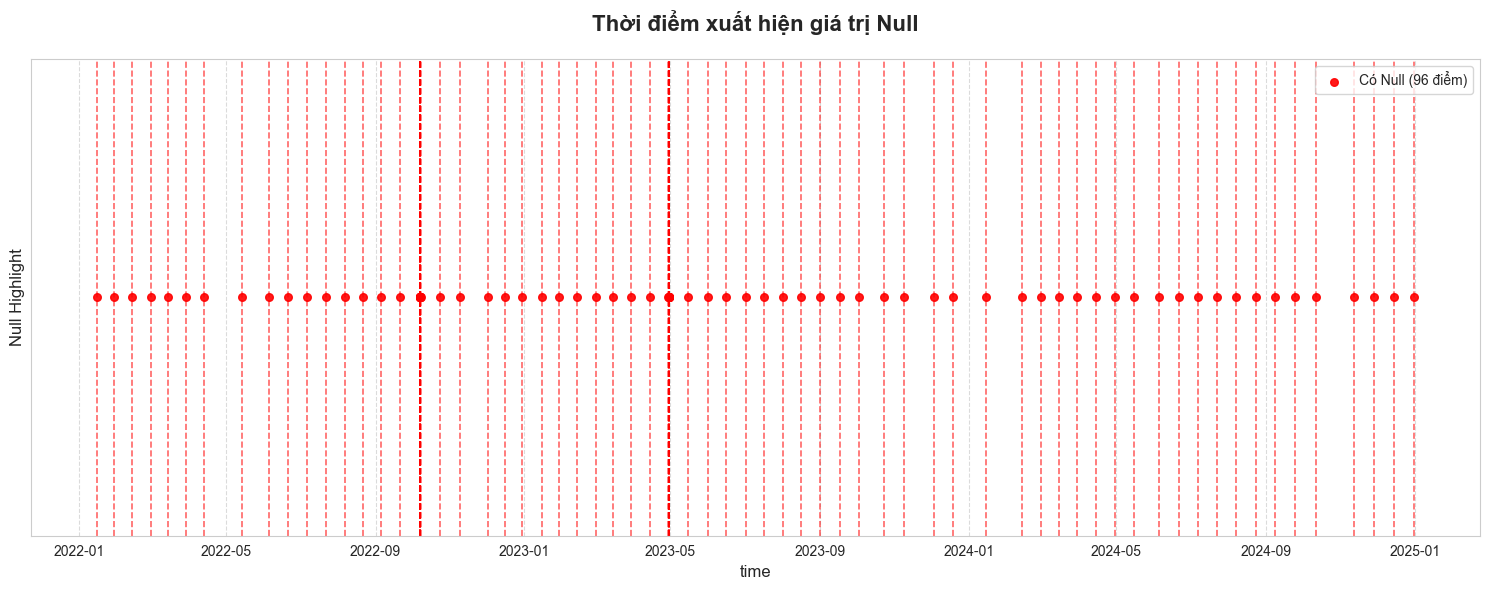

In [14]:
null_times = plot_null(train_df)

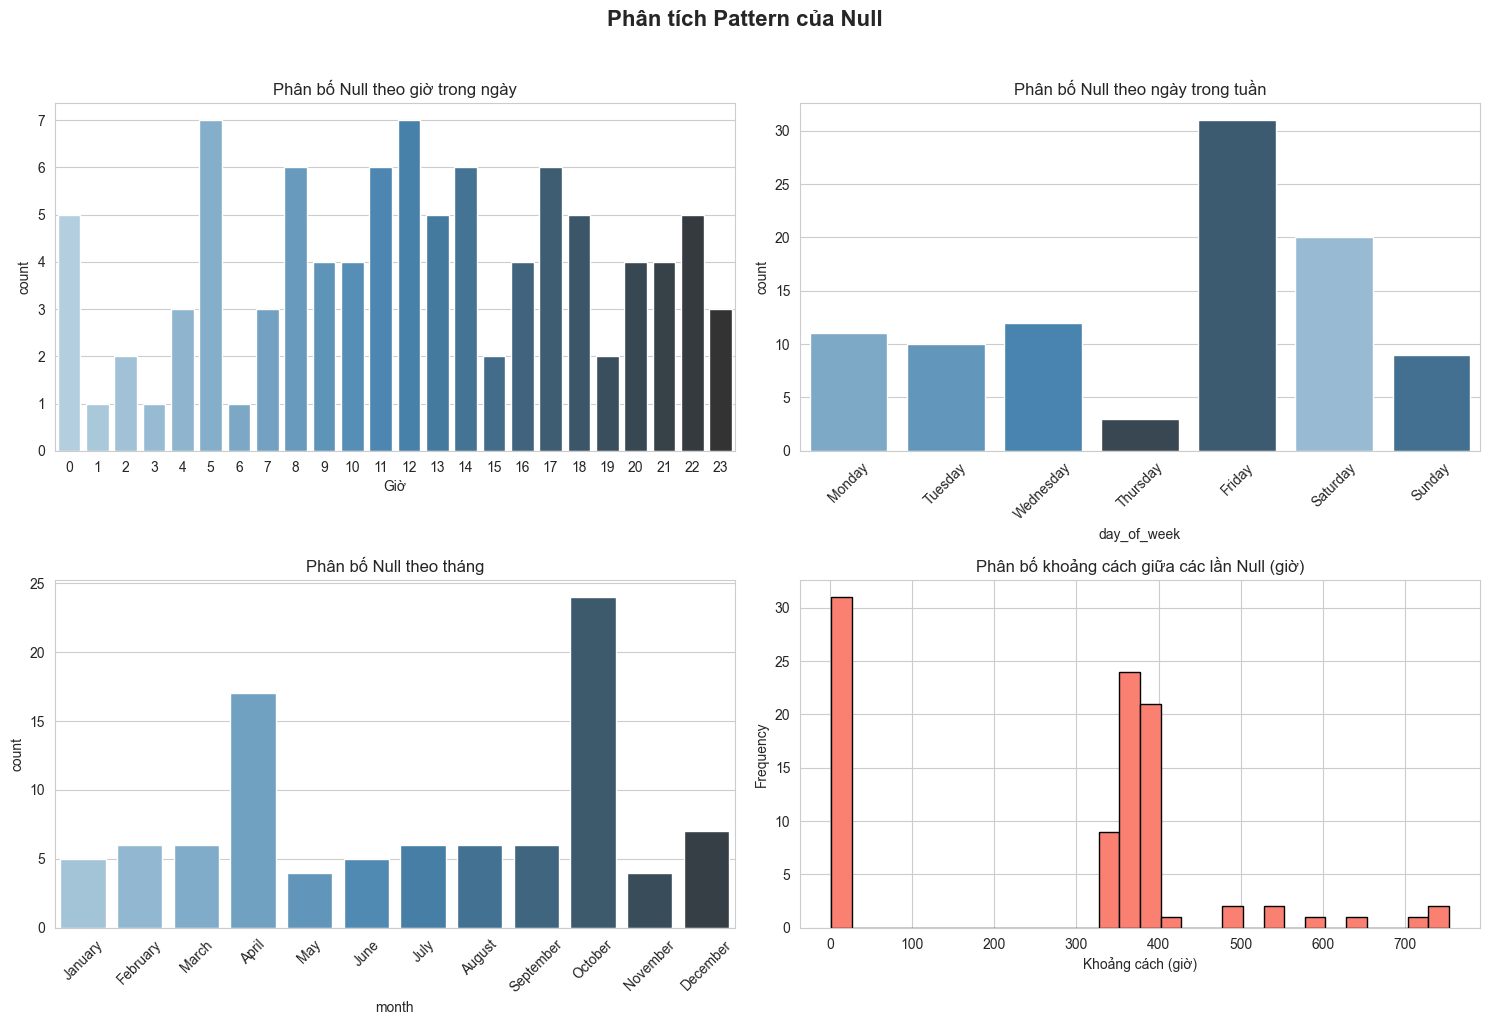

In [15]:
analyze_null_pattern(null_times)

In [16]:
# Chạy Little's MCAR Test an toàn, tự động loại bỏ cột hằng số.
def run_little_mcar_test_safe(df: pd.DataFrame, 
                              columns: list = None, 
                              alpha: float = 0.05):

    if columns is None:
        numeric_df = df.select_dtypes(include=['number']).copy()
    else:
        numeric_df = df[columns].select_dtypes(include=['number']).copy()
    
    print(f"Số cột numeric ban đầu: {numeric_df.shape[1]}")
    
    # Loại bỏ cột có variance = 0
    variances = numeric_df.var(skipna=True, ddof=0)
    constant_cols = variances[variances <= 1e-8].index.tolist()   # ngưỡng nhỏ để tránh floating point
    
    if constant_cols:
        print(f"Loại bỏ {len(constant_cols)} cột hằng số: {constant_cols}")
        numeric_df = numeric_df.drop(columns=constant_cols)
    
    if numeric_df.shape[1] < 2:
        print("Không đủ cột số có variance > 0 để chạy test.")
        return None
    
    try:
        mt = MCARTest(method='little')
        p_value = mt.little_mcar_test(numeric_df)
        
        print("="*70)
        print("LITTLE'S MCAR TEST")
        print("="*70)
        print(f"Số cột sử dụng     : {numeric_df.shape[1]}")
        print(f"p-value            : {p_value:.6f}")
        
        if p_value > alpha:
            print("p-value > 0.05 → Không bác bỏ H0 → Có thể coi là MCAR")
        else:
            print("p-value ≤ 0.05 → Bác bỏ H0 → KHÔNG phải MCAR (MAR hoặc MNAR)")
            
    except Exception as e:
        print(f"Lỗi vẫn xảy ra: {e}")

In [17]:
run_little_mcar_test_safe(train_df)

Số cột numeric ban đầu: 17
Loại bỏ 2 cột hằng số: ['h_dbt', 'h_c']
LITTLE'S MCAR TEST
Số cột sử dụng     : 15
p-value            : 0.032490
p-value ≤ 0.05 → Bác bỏ H0 → KHÔNG phải MCAR (MAR hoặc MNAR)


Null xuất hiện rải rác trong toàn bộ dữ liệu và tại 1 số tháng ta thấy lượng null nhiều lên bất thường (tháng 4, 10) hay vào 1 số khung giờ hoặc ngày nên có khả năng không phải MCAR. Sau khi kiểm định giả thiết với little test MCAR, p-value = 0.03 < 0.05 nên bác bỏ H0.  
-> các missing values trong bài không phải là MCAR -> MAR hoặc MNAR.

Như vậy các missing values này có thể được điền khuyết, tại đây thử nghiệm 2 phương pháp:
- Feature-based method: dựa vào dữ liệu về thời tiết, dự đoán dữ liệu evn tại cùng thời điểm để điền vào null.
- Sliding window method: sử dụng cửa sổ trượt thông qua phương pháp rolling mean/median để điền khuyết, sử dụng theo hướng forward pass để tránh data leakage. -> tận dụng tính autocorrelation của dữ liệu time series.

## Correlation 

In [18]:
def plot_correlation_matrix(df, columns=None, figsize=(12, 10), 
                           title="Correlation Matrix", 
                           cmap="coolwarm", annot=True):

    # Nếu không truyền columns thì lấy tất cả cột số
    if columns is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    else:
        numeric_cols = [col for col in columns if col in df.columns 
                       and pd.api.types.is_numeric_dtype(df[col])]
    
    if len(numeric_cols) < 2:
        print("Cần ít nhất 2 cột số để vẽ correlation matrix!")
        return
    
    # Tính correlation matrix
    corr_matrix = df[numeric_cols].corr()
    
    # Vẽ heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, 
                annot=annot,                  # Hiển thị giá trị
                fmt=".2f",                    # Làm tròn 2 chữ số
                cmap=cmap, 
                vmin=-1, vmax=1,              # Giới hạn correlation
                center=0,
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8})
    
    plt.title(title, fontsize=16, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [19]:
# Plot autocorrelation và partial autocorrelation
def plot_acf_pacf(df: pd.DataFrame,
                  column: str,
                  lags: int = 40,
                  alpha: float = 0.05,
                  figsize: tuple = (14, 9)):
    
    if column not in df.columns:
        raise ValueError(f"Cột '{column}' không tồn tại!")
    if "time" not in df.columns:
        raise ValueError("Cột 'time' không tồn tại!")

    # Chuẩn bị dữ liệu
    data = df[["time", column]].copy()
    if not pd.api.types.is_datetime64_any_dtype(data["time"]):
        data["time"] = pd.to_datetime(data["time"])
    
    data = data.sort_values("time")
    series = data[column].interpolate(method='linear').dropna()

    # Điều chỉnh lags nếu dữ liệu ngắn
    if len(series) < lags + 10:
        lags = max(20, len(series) // 3)

    # Vẽ biểu đồ
    plt.figure(figsize=figsize)

    # ACF
    plot_acf(series, lags=lags, alpha=alpha, title= f'Autocorrelation Plot - {column}',
             ax=plt.gca(),
             color='blue',
             vlines_kwargs={'linewidth': 1.2})

    plt.title(f'Autocorrelation Plot - {column}', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Lag', fontsize=12)
    plt.ylabel('Autocorrelation', fontsize=12)
    
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

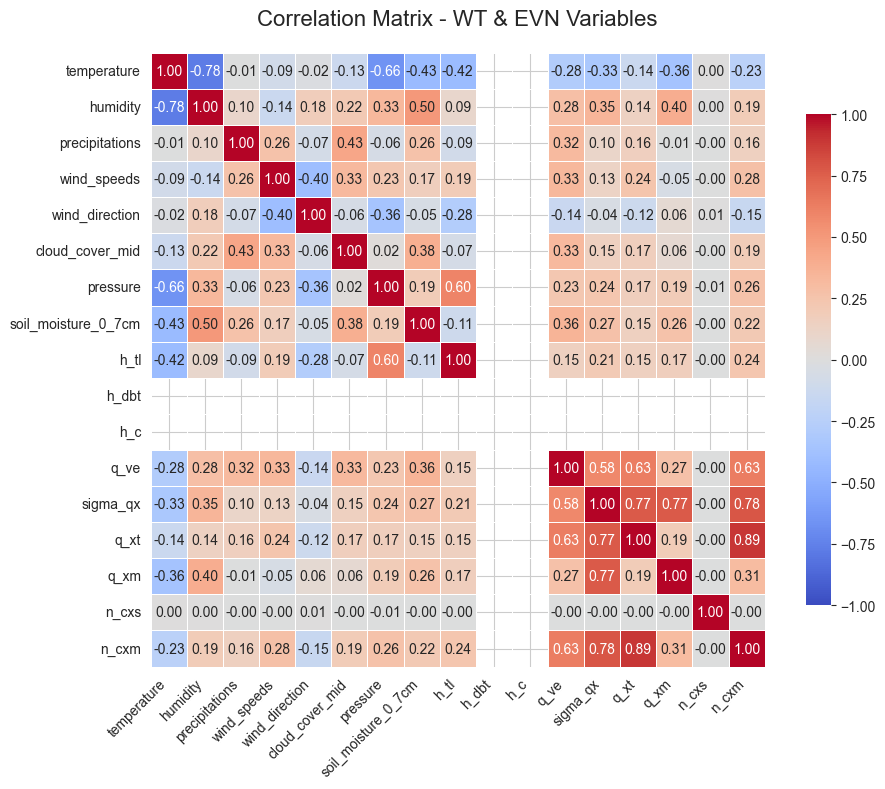

In [20]:
plot_correlation_matrix(train_df, columns=WT_COLS+EVN_COLS, 
                       title="Correlation Matrix - WT & EVN Variables",
                       figsize=(10, 8))

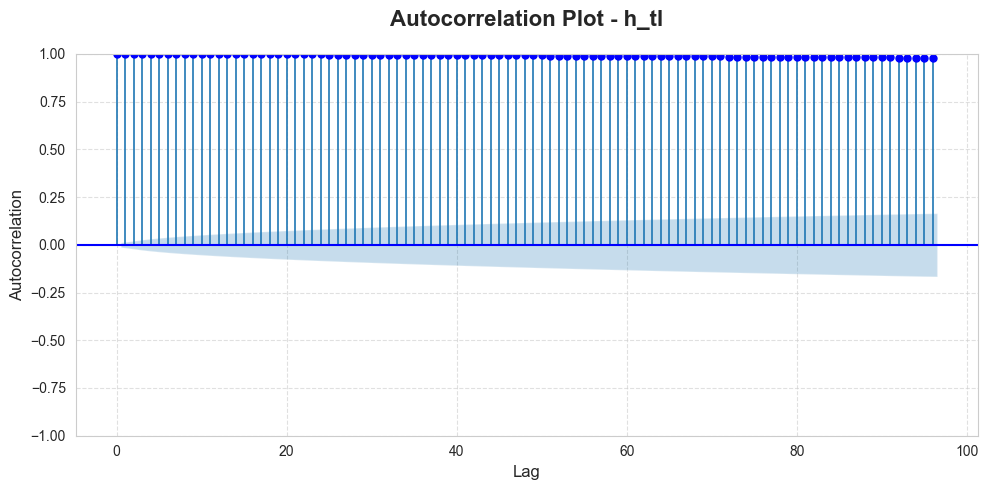

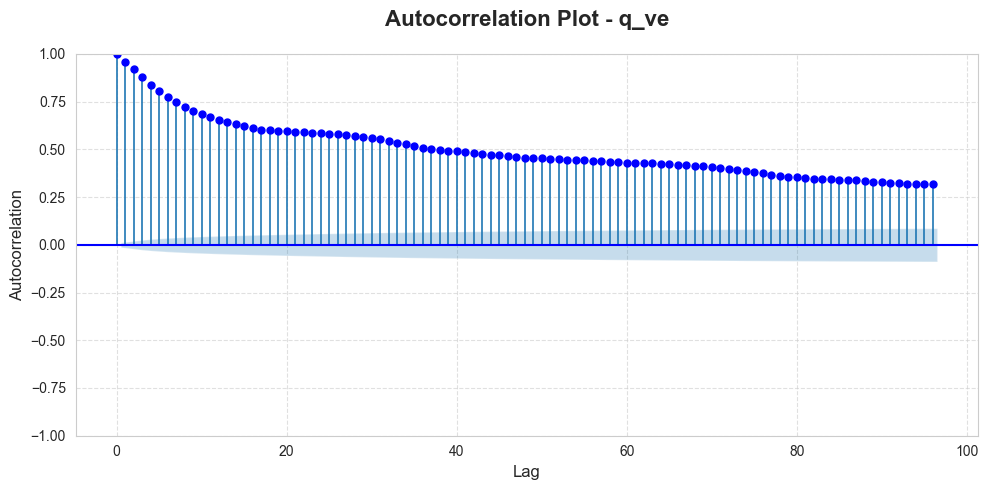

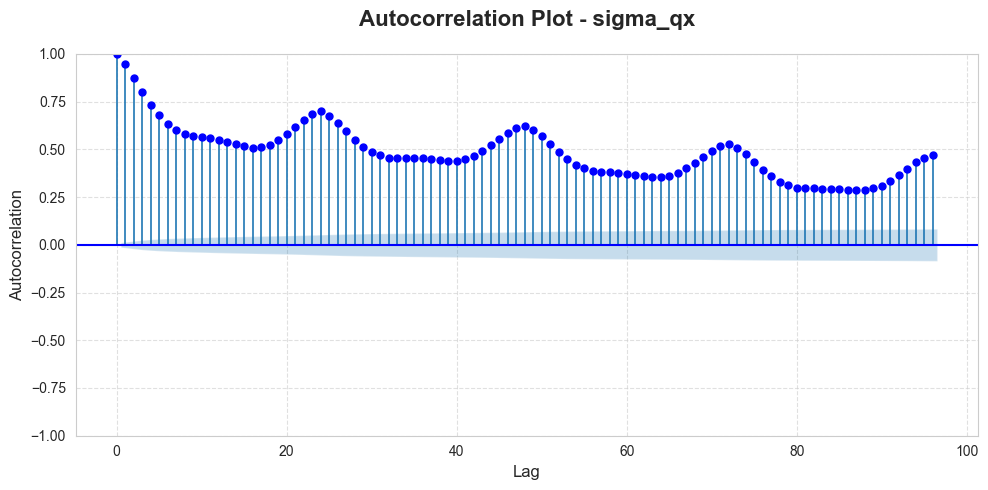

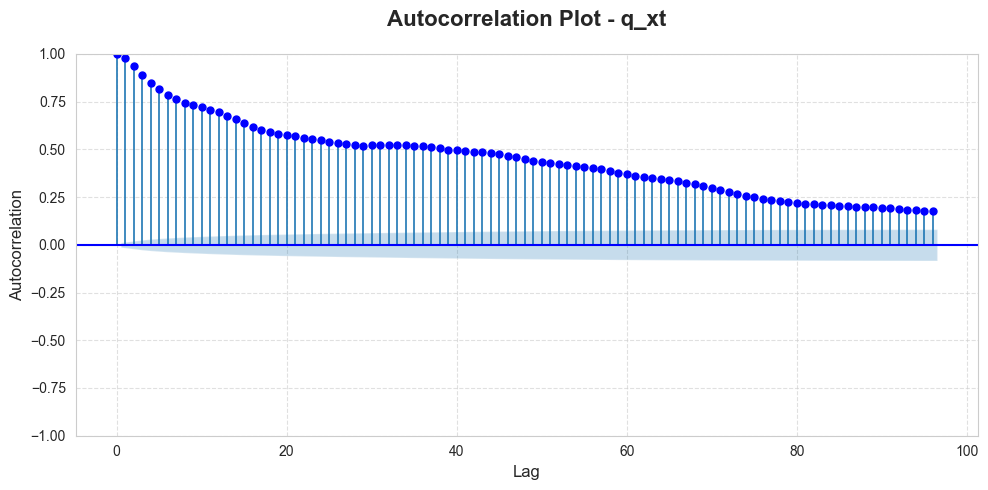

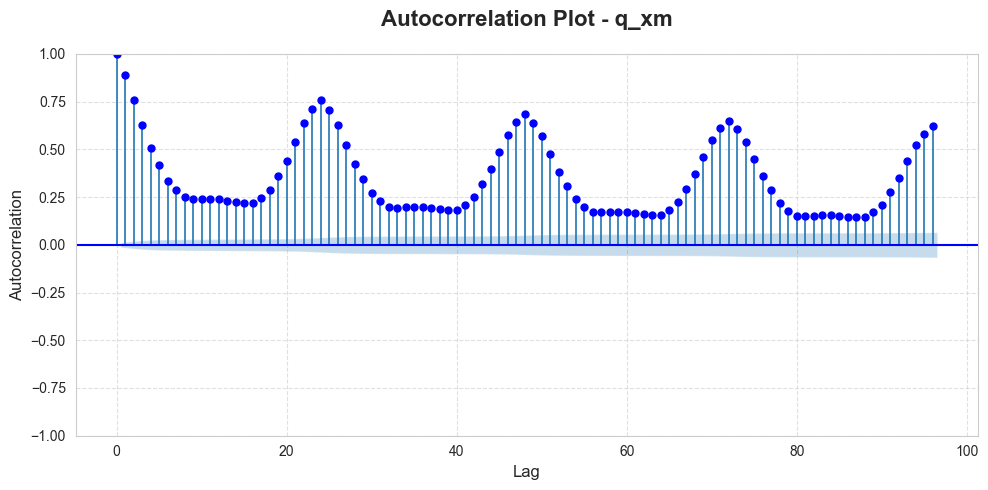

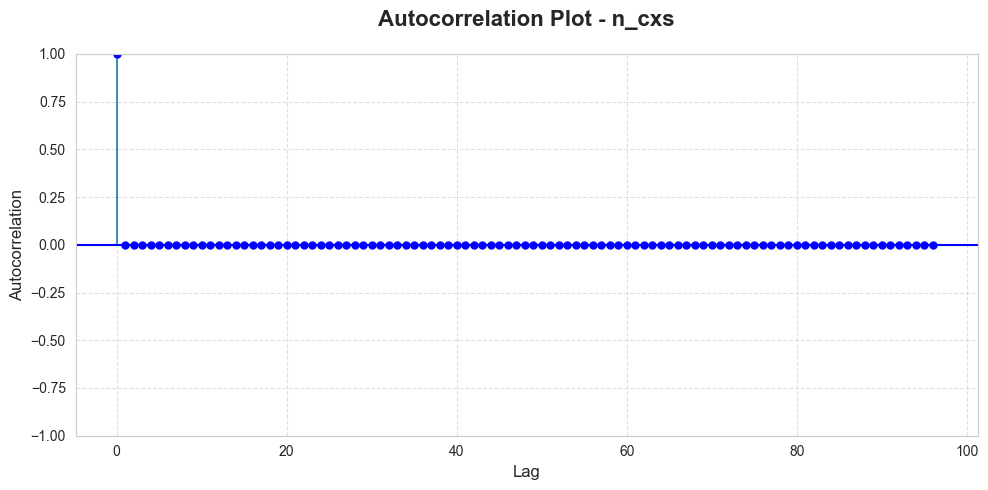

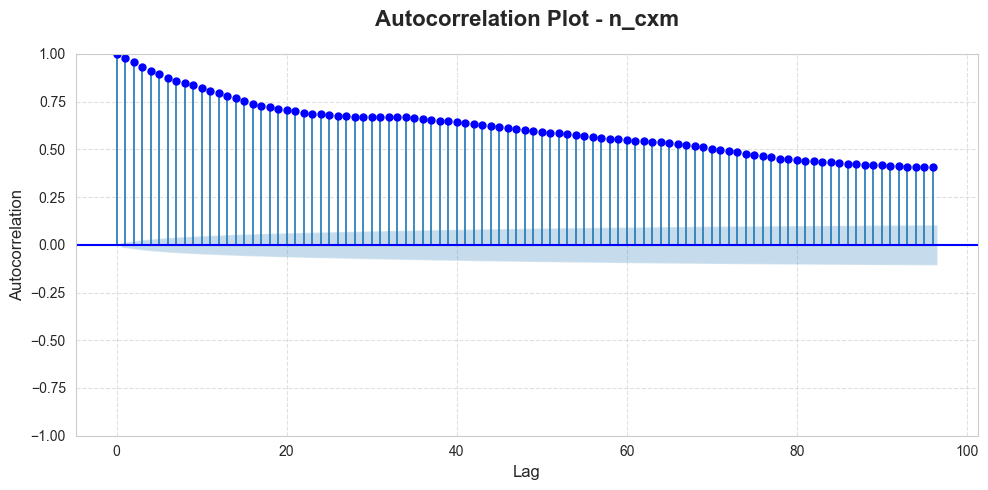

In [21]:
for col in EVN_VARS:
    plot_acf_pacf(train_df, column=col, lags=96, figsize=(10, 5))

- Tương quan tuyến tính giữa các biến môi trường tới các biến về hồ thủy điện thường ở mức vừa phải, không đáng kể. 
- Mức tương quan giữa H_tl với pressure là 0.6, khá cao nhưng đây có thể không phải là mối quan hệ nhân quả.

-> Tương quan giữa các biến thời tiết với biến evn có thể không phải tương quan tuyến tính.

- H_tl: acf ~ 1 ở mọi lag, cho thấy dữ liệu khá ít thay đổi và tương đối ổn định.
- q_ve: Giảm dần đều, vẫn còn ~0.35 ở lag 100 cho thấy q_ve có xu hướng dài hạn, thay đổi chậm và liên tục.
- sigma_qx: Giảm dần và lặp lại theo chu kỳ ~24 giờ.
- q_xt: Giảm dần đều, còn ~0.2 ở lag 100, tương tự q_ve nhưng giảm nhanh hơn cho thấy quán tính ngắn hơn, không có chu kỳ.
- q_xm: Dao động mạnh theo chu kỳ ~24 lag, biên độ cao, ổn định -> mùa vụ cao.
- n_cxs: chỉ có lag0 = 1 còn lại = 0 cho thấy đây là nhiễu trắng -> ngẫu nhiên, độc lập, không có cấu trúc.
- n_csm: tương tự q_ve và q_xt.

## Feature - time

In [22]:
# Vẽ biểu đồ các biến theo thời gian, có thể kết hợp nhiều columns vô cùng biểu đồ, cần chú ý scale
def plot_time_series(df: pd.DataFrame, 
                     columns: list, 
                     time_column: str = "time",
                     title: str = "Mối quan hệ thời gian",
                     figsize: tuple = (14, 7),
                     palette: str = "tab10",
                     linewidth: float = 1,
                     grid: bool = True,
                     style: str = "whitegrid"):
    
    sns.set_style(style)
    plt.figure(figsize=figsize)
    
    x_data = df[time_column]
    colors = sns.color_palette(palette, n_colors=len(columns))
    
    for i, col in enumerate(columns):
        if col not in df.columns:
            print(f"Cột '{col}' không tồn tại trong DataFrame!")
            continue
            
        original_label =  col
        plt.plot(x_data, df[col], 
                 label=original_label,
                 color=colors[i], 
                 linewidth=linewidth,
                 alpha=0.85,           
                 marker='o' if len(df) < 50 else None,
                 markersize=4)

    # Tùy chỉnh biểu đồ
    plt.title(title, fontsize=16, pad=20, fontweight='bold')
    plt.xlabel(time_column, fontsize=12)
    plt.ylabel("Giá trị", fontsize=12)
    
    plt.legend(title="Các chỉ số", 
               title_fontsize=11,
               fontsize=10,
               loc='best',
               frameon=True,
               shadow=True)
    
    if grid:
        plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

In [23]:
# Vẽ biểu đồ biến động của một cột kèm rolling mean/median (nếu muốn)
def plot_column_with_rolling(df: pd.DataFrame,
                             column: str,
                             time_column: str = "time",
                             start_date=None,
                             end_date=None,
                             rolling_window: int = 7,
                             rolling_methods: list = None,
                             title: str = None,
                             figsize: tuple = (15, 8),
                             grid: bool = True):

    if column not in df.columns:
        raise ValueError(f"Cột '{column}' không tồn tại!")
    if time_column not in df.columns:
        raise ValueError(f"Cột thời gian '{time_column}' không tồn tại!")

    df_plot = df.copy()

    # Chuẩn bị datetime
    if not pd.api.types.is_datetime64_any_dtype(df_plot[time_column]):
        df_plot[time_column] = pd.to_datetime(df_plot[time_column])

    # Lọc khoảng thời gian
    if start_date:
        df_plot = df_plot[df_plot[time_column] >= pd.to_datetime(start_date)]
    if end_date:
        df_plot = df_plot[df_plot[time_column] <= pd.to_datetime(end_date)]

    if len(df_plot) == 0:
        print("Không có dữ liệu trong khoảng thời gian đã chọn.")
        return

    # Vẽ biểu đồ
    plt.figure(figsize=figsize)
    colors = sns.color_palette("tab10", 4)

    # Đường gốc
    plt.plot(df_plot[time_column], df_plot[column],
             label=f'{column} (Giá trị thực)',
             color=colors[0], linewidth=1, alpha=0.65)

    # Rolling methods
    if rolling_methods:
        if isinstance(rolling_methods, str):
            rolling_methods = [rolling_methods]

        for i, method in enumerate(rolling_methods):
            if method == "mean":
                data = df_plot[column].rolling(window=rolling_window, min_periods=1).mean()
                label = f'Rolling Mean ({rolling_window})'
                color = colors[1]
                lw = 1
                ls = '-'
            elif method == "median":
                data = df_plot[column].rolling(window=rolling_window, min_periods=1).median()
                label = f'Rolling Median ({rolling_window})'
                color = colors[2]
                lw = 1
                ls = '--'
            elif method == "std":
                data = df_plot[column].rolling(window=rolling_window, min_periods=1).std()
                label = f'Rolling Std ({rolling_window})'
                color = colors[3]
                lw = 1
                ls = ':'
            else:
                continue

            plt.plot(df_plot[time_column], data, 
                     label=label, color=color, linewidth=lw, linestyle=ls)

    # Tiêu đề
    if title is None:
        methods_str = " + ".join(rolling_methods) if rolling_methods else "Không rolling"
        title = f'Biến động {column} | Rolling {rolling_window} - {methods_str}'

    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Thời gian", fontsize=12)
    plt.ylabel(column, fontsize=12)
    plt.legend(title="So sánh", fontsize=10, frameon=True, shadow=True, loc='best')

    if grid:
        plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [24]:
# Plot 2 cột scale quá khác nhau
def plot_rolling_2_axis(df: pd.DataFrame, 
                        columns: list, 
                        time_column: str = "time",
                        title: str = "Biểu đồ Rolling Mean theo thời gian",
                        figsize: tuple = (15, 8),
                        palette: str = "tab10",
                        rolling: int = 7,
                        grid: bool = True,
                        style: str = "whitegrid"):
    if len(columns) != 2:
        print("Phải truyền 2 cột để quan sát!")
        return
    
    sns.set_style(style)
    fig, ax1 = plt.subplots(figsize=figsize)
    
    x_data = df[time_column]
    colors = sns.color_palette(palette, n_colors=2)
    
    # Tạo 2 trục Y
    ax2 = ax1.twinx()
    axes = [ax1, ax2]
    
    lines = []
    labels = []
    
    for i, col in enumerate(columns):
        if col not in df.columns:
            print(f"Cột '{col}' không tồn tại!")
            continue
            
        ax = axes[i]
        color = colors[i]
        
        # Tính Rolling Mean
        rolling_mean = df[col].rolling(window=rolling, min_periods=1).mean()
        
        # Thiết lập độ đậm/mờ theo thứ tự cột
        if i == 0:   # Cột đầu tiên = MỜ
            alpha = 0.55
            linewidth = 1
            linestyle = '--'
            label = f"{col} (Rolling {rolling})"
        else:        # Cột thứ hai = ĐẬM
            alpha = 1.0
            linewidth = 1
            linestyle = '-'
            label = f"{col} (Rolling {rolling})"
        
        # Vẽ đường
        line, = ax.plot(x_data, rolling_mean,
                        label=label,
                        color=color, 
                        linewidth=linewidth,
                        linestyle=linestyle,
                        alpha=alpha)
        
        lines.append(line)
        labels.append(label)
        
        # Label trục Y
        ax.set_ylabel(col, color=color, fontsize=12, fontweight='bold')
        ax.tick_params(axis='y', labelcolor=color)
    
    # Tiêu đề và trục X
    plt.title(title, fontsize=16, pad=20, fontweight='bold')
    ax1.set_xlabel(time_column, fontsize=12)
    
    if grid:
        ax1.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

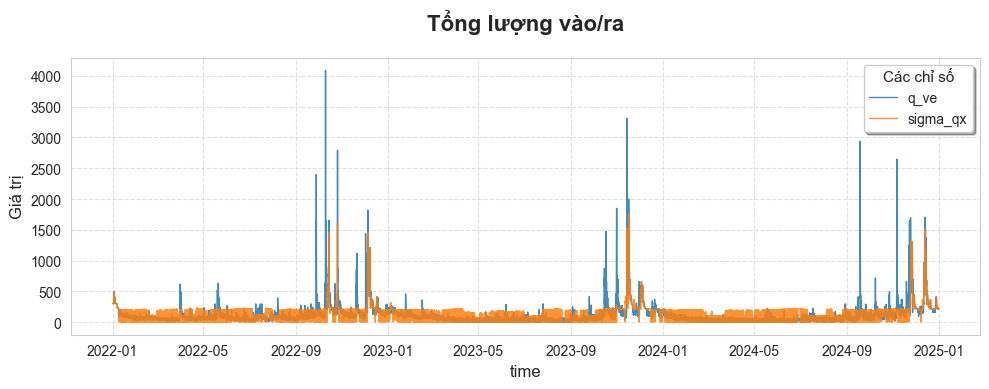

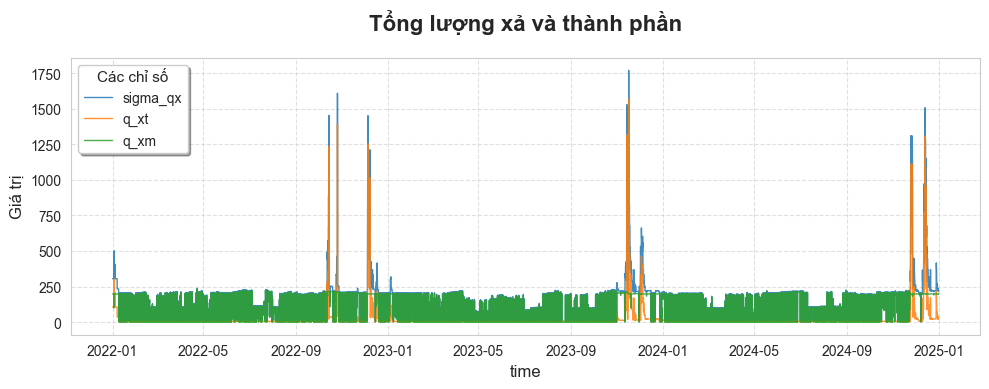

In [25]:
plot_time_series(train_df, 
                 columns=['q_ve', 'sigma_qx'], 
                 time_column='time',
                 title='Tổng lượng vào/ra',
                 figsize = (10, 4))

plot_time_series(train_df, 
                 columns=['sigma_qx', 'q_xt', 'q_xm'], 
                 time_column='time',
                 title='Tổng lượng xả và thành phần',
                 figsize = (10, 4))

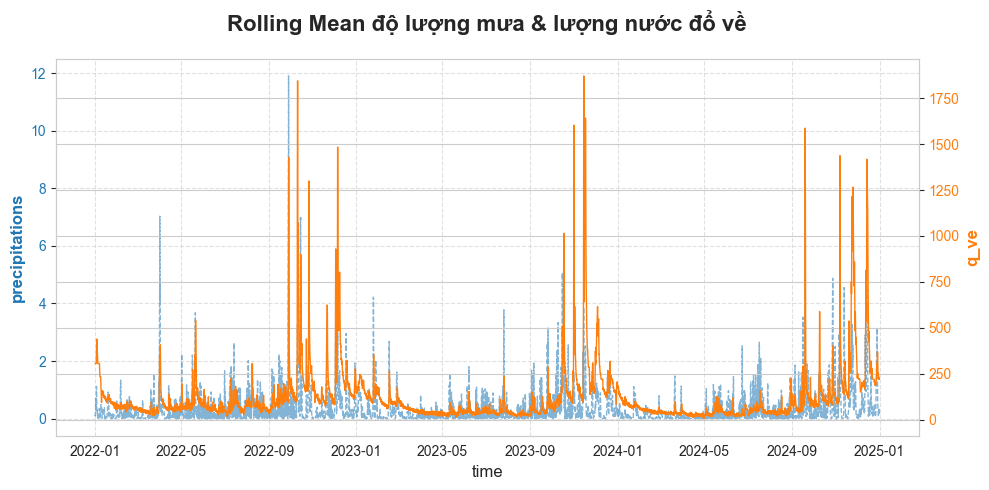

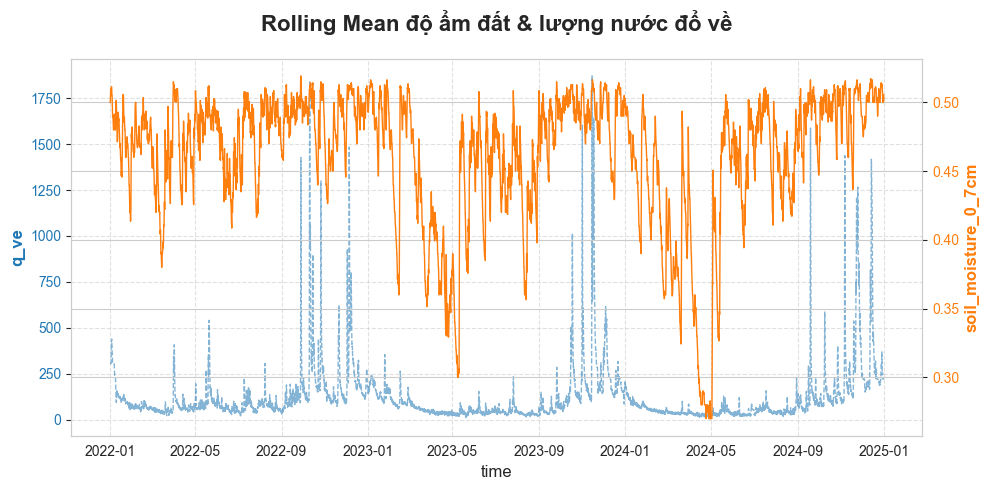

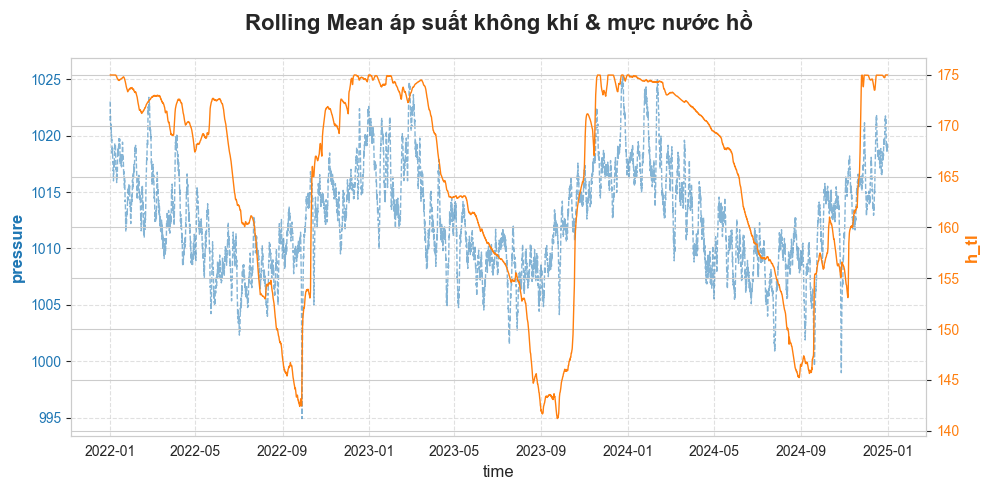

In [26]:
plot_rolling_2_axis(train_df, 
                    columns=['precipitations', 'q_ve'], 
                    time_column='time',
                    rolling=14,
                    title='Rolling Mean độ lượng mưa & lượng nước đổ về',
                    figsize=(10, 5))

plot_rolling_2_axis(train_df, 
                    columns=['q_ve','soil_moisture_0_7cm'], 
                    time_column='time',
                    rolling=14,
                    title='Rolling Mean độ ẩm đất & lượng nước đổ về',
                    figsize=(10, 5))

plot_rolling_2_axis(train_df, 
                    columns=['pressure','h_tl'], 
                    time_column='time',
                    rolling=14,
                    title='Rolling Mean áp suất không khí & mực nước hồ',
                    figsize=(10, 5))

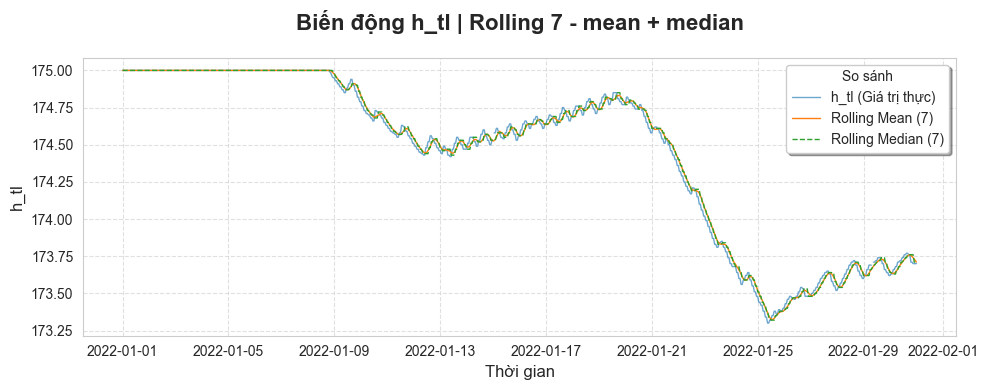

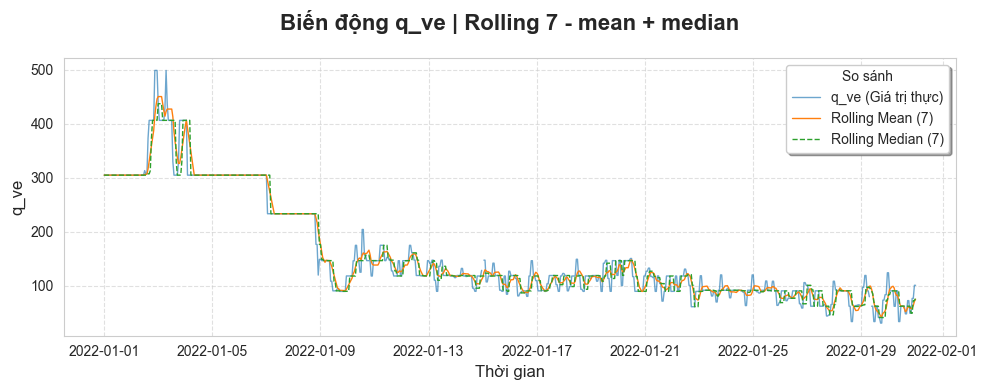

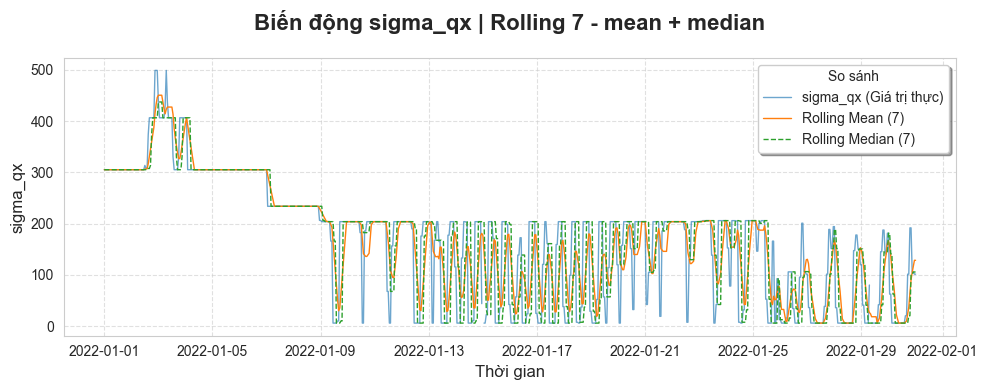

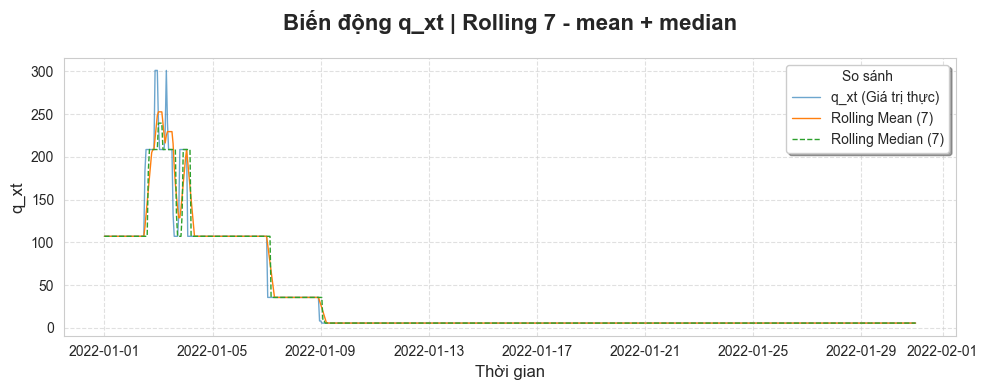

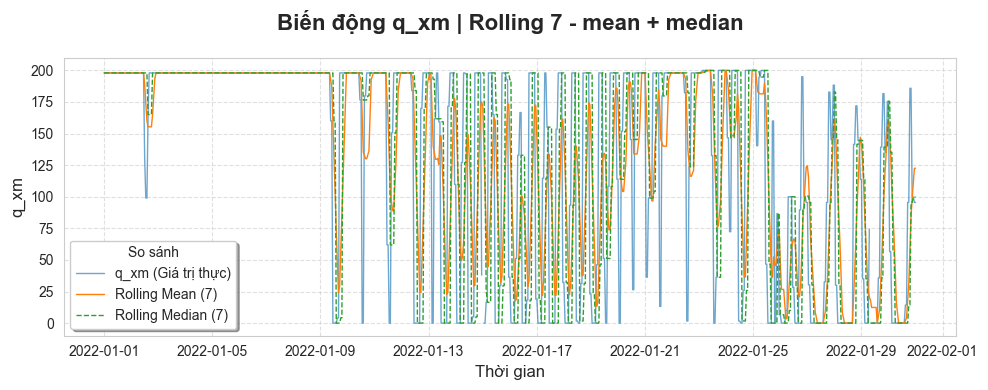

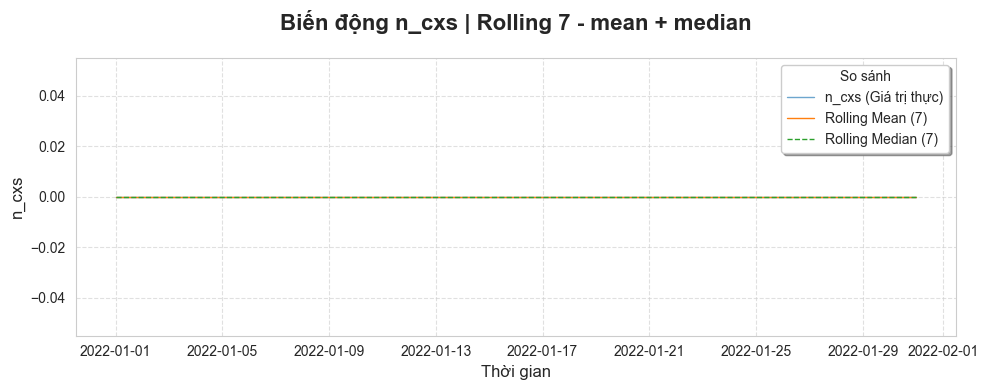

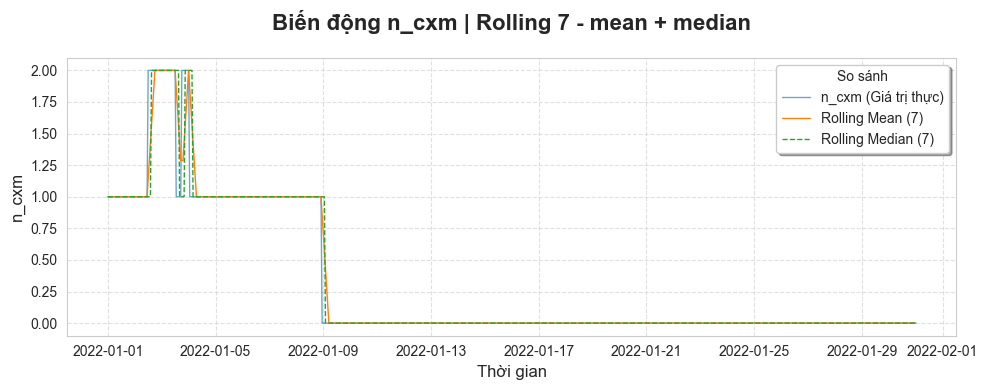

In [27]:
for col in EVN_VARS:
    plot_column_with_rolling(train_df, 
                            column=col,
                            time_column='time',
                            start_date='2022-01-01',
                            end_date='2022-01-31',
                            rolling_methods=["mean", "median"], figsize=(10,4), rolling_window=7)

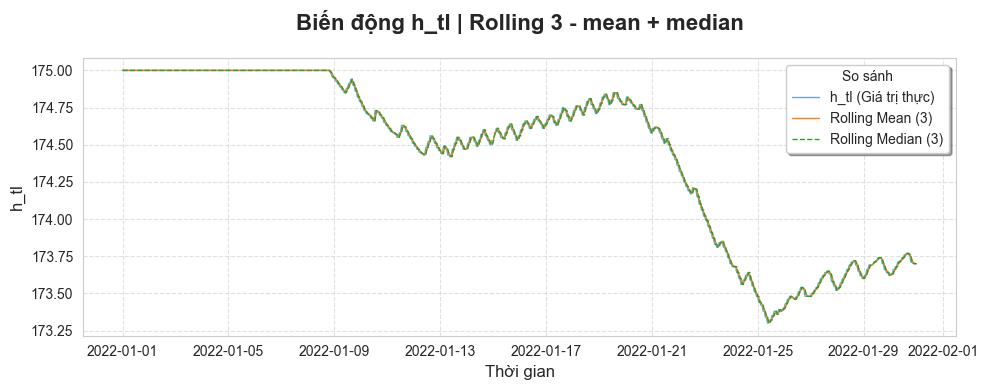

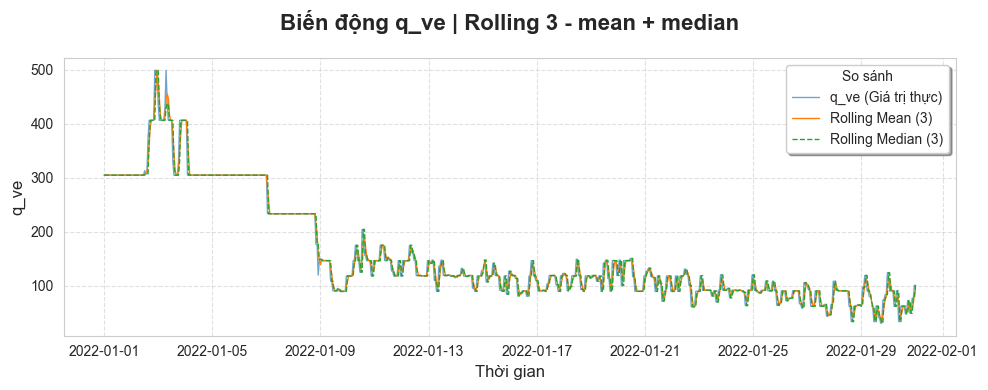

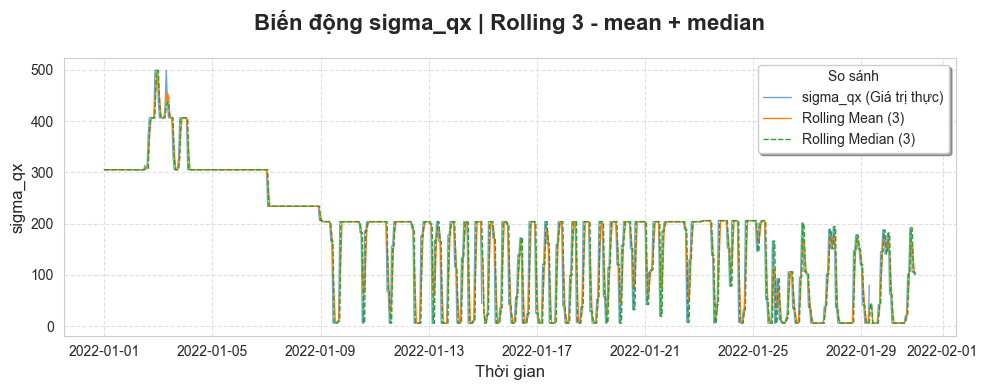

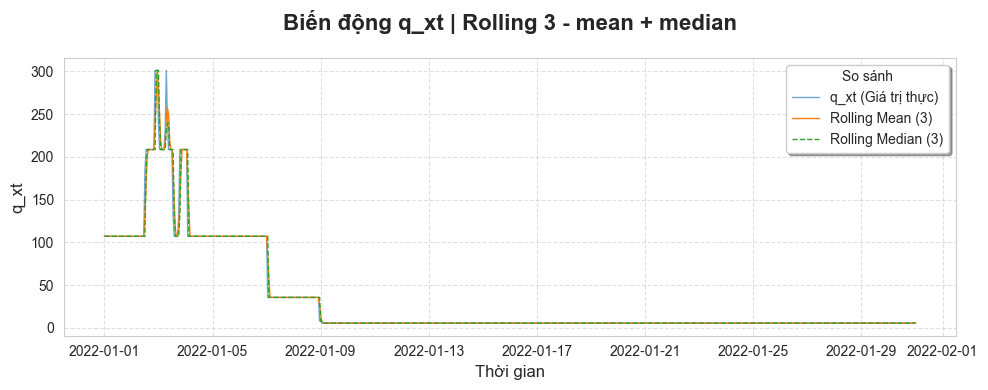

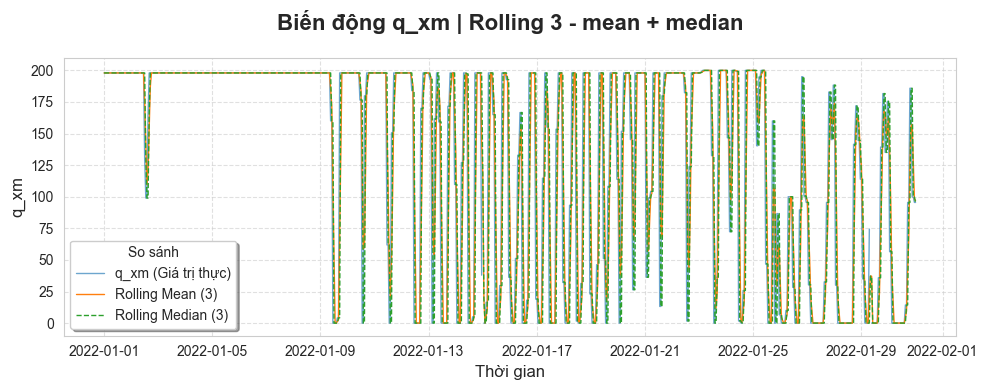

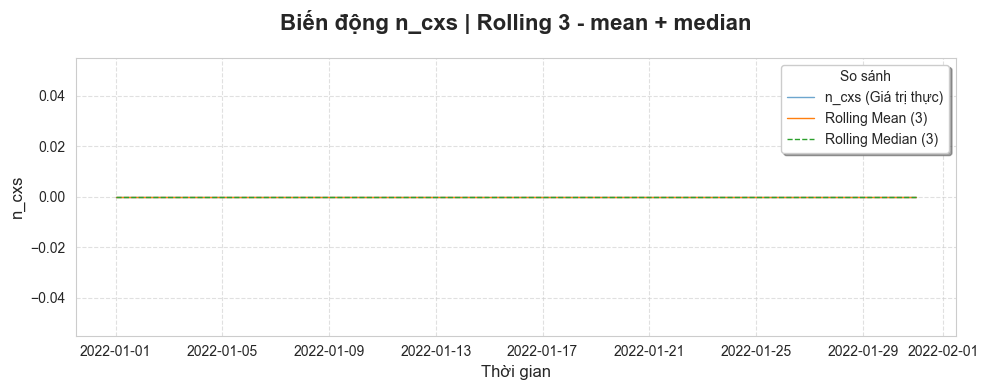

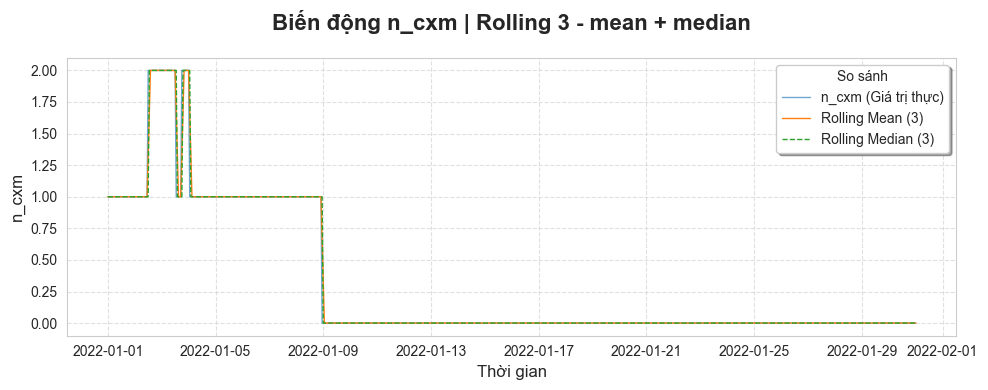

In [28]:
for col in EVN_VARS:
    plot_column_with_rolling(train_df, 
                            column=col,
                            time_column='time',
                            start_date='2022-01-01',
                            end_date='2022-01-31',
                            rolling_methods=["mean", "median"], figsize=(10,4), rolling_window=3)

Các biến về hồ thủy điện cũng có yếu tố mùa vụ và sự kiện nổi bật, trong đó:
- Mực nước thượng lưu luôn được duy trì ở mức bình ổn trong 1 khoảng giá trị xác định. Trong đó vào khoảng tháng 7 - 11 mực nước được duy trì ở mức thấp và đạt cực tiểu vào tháng 10. Vào các tháng còn lại sẽ duy trì ở mức cao. Ta thấy 1 điểm bất thường vào tháng 4/2025 có thể là do nhiễu đo lường hoặc hạn hán bất thường (không có thông tin).
- Tổng lượng nước đổ về và xả ra khá liên quan với nhau đặc biệt tại các mốc với giá trị lớn, cho thấy nỗ lực duy trì mức độ ổn định của đập thủy điện.
- Tổng lượng xả và lượng xả qua đập tràn có xu hướng biến đổi giống nhau. Hoàn toàn khác với lượng xả qua nhà máy vốn ổn định và duy trì ở mức vừa phải, được quản lý bởi lịch xả nước được quy định bởi con người.

Khi quan sát biểu đồ kết hợp giữa 1 số biến weather với biến evn cụ thể là q_ve, ta thấy chúng có liên hệ phần nào với nhau. Đối với pressure và h_tl, xu hướng biến đổi cho thấy khá tương đồng, tuy nhiên không có lý thuyết thực tế nào cho thấy rằng áp xuất tăng thì mực nước trong hồ sẽ tăng và ngược lại cả -> có thể do trùng hợp.

Khi xem biểu đồ so sánh giữa rolling mean và median so với dữ liệu, ta thấy median thường gần với dữ liệu thật hơn và nó cũng kháng nhiễu tốt hơn.  
Khi quan sát với 2 window size khác nhau, ta thấy window size càng nhỏ thì rolling sẽ bám càng sát giá trị thật nhưng dễ bị ảnh hưởng bởi nhiễu và các giá trị null liên tiếp hơn.

# Bước 3: Null handling

Thực hiện mask tập test để giả lập các giá trị null theo tỉ lệ nhất định. Thử nghiệm các chiến thuật điền null:
- feature-based method: dựa vào dữ liệu weather, time và áp dụng các mô hình máy học (KNN).
- sliding window method: dùng rolling median với window_size = 3, không lấy center. Với các điểm vẫn còn null -> fill với mean của biến tại cùng giờ/tháng. Các mean này được tính trước trên tập train.
- nội suy: thử nghiệm linear interpolation, đã điều chỉnh để chỉ nhìn từ quá khứ.

In [37]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)

In [44]:
# Tạo mask cho tập test
def create_test_with_mask(test_df, mask_ratio=0.1, random_state=42):
    rng = np.random.default_rng(random_state)
    
    # chỉ mask ở các dòng EVN đầy đủ
    valid_rows = test_df[EVN_COLS].notna().all(axis=1)
    valid_idx = test_df[valid_rows].index.to_numpy()
    n_mask = int(len(valid_idx) * mask_ratio)
    mask_idx = rng.choice(valid_idx, size=n_mask, replace=False)

    # lưu ground truth
    ground_truth = test_df.loc[mask_idx, EVN_COLS].copy()
    test_df.loc[mask_idx, EVN_COLS] = np.nan

    return test_df, ground_truth, mask_idx

# Thêm dữ liệu thời gian, bỏ ten_ho và time
def feature_engineer(df):
    df = df.copy()
    df["time"] = pd.to_datetime(df["time"])
    
    day = df["time"].dt.day
    df["day_sin"] = np.sin(2 * np.pi * day / 31)
    df["day_cos"] = np.cos(2 * np.pi * day / 31)
    
    month = df["time"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * month / 12)
    df["month_cos"] = np.cos(2 * np.pi * month / 12)
    
    df["year"] = df["time"].dt.year
    
    df = df.drop(columns=["ten_ho", "time"], errors="ignore")
    return df

In [45]:
def train_knn_imputer(train_df, EVN_COLS, feature_cols=None,
    scoring="neg_mean_absolute_error"):
    df = train_df.copy()
    df = feature_engineer(df)   
    
    # feature columns
    if feature_cols is None:
        feature_cols = [c for c in df.columns if c not in EVN_COLS]
    # chỉ lấy các dòng target đầy đủ
    valid_rows = df[EVN_COLS].notna().all(axis=1)
    train_data = df.loc[valid_rows]

    X = train_data[feature_cols]
    y = train_data[EVN_COLS]

    # pipeline
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),  #tránh null trong feature
        ("scaler", StandardScaler()),   # chuẩn hóa, bắt buộc trong KNN
        ("model", MultiOutputRegressor(KNeighborsRegressor()))
    ])

    # hyperparameter grid
    param_grid = {
        "model__estimator__n_neighbors": [3, 5, 7, 9],
        "model__estimator__weights": ["uniform", "distance"],
        "model__estimator__p": [1, 2],  # Manhattan / Euclidean
    }

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=tscv,
        scoring=scoring,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X, y)

    print("Best params:", grid.best_params_)
    print("Best score:", grid.best_score_)

    return grid.best_estimator_

def fill_missing_knn(df, model, EVN_COLS, feature_cols=None):
    result = df.copy()
    if feature_cols is None:
        feature_cols = [c for c in df.columns if c not in EVN_COLS]

    # dòng có thiếu EVN
    missing_rows = result[EVN_COLS].isna().any(axis=1)
    if missing_rows.sum() == 0:
        return result
    
    X_missing = result.loc[missing_rows, feature_cols]

    pred = model.predict(X_missing)
    result.loc[missing_rows, EVN_COLS] = pred

    return result

In [39]:
def fill_past_linear(df, EVN_COLS):
    result = df.copy()

    for col in EVN_COLS:
        series = result[col].copy()
        
        # Check 2 dòng đầu
        if len(series) > 0 and pd.isna(series.iloc[0]):
            series.iloc[0] = 0
        if len(series) > 1 and pd.isna(series.iloc[1]):
            series.iloc[1] = 0

        for i in range(2, len(series)):
            # Chỉ xử lý nếu giá trị hiện tại là NaN
            if pd.isna(series.iloc[i]):
                prev1 = series.iloc[i - 1]
                prev2 = series.iloc[i - 2]

                # Cần đủ 2 giá trị quá khứ hợp lệ
                if pd.notna(prev1) and pd.notna(prev2):
                    slope = prev1 - prev2
                    series.iloc[i] = prev1 + slope

        result[col] = series

    return result

In [ ]:
# Tính trước các giá trị trung bình trên tập train để tránh data leakage
def fit_rolling_median(train_df, SEASONAL_COLS):
    train = train_df.copy()
    train["time"] = pd.to_datetime(train["time"])
    train["week"] = train["time"].dt.isocalendar().week.astype(int)
    train["month"] = train["time"].dt.month

    seasonal_lookup = {}
    for col in SEASONAL_COLS:
        lookup = train.groupby(["week", "month"])[col].mean()
        seasonal_lookup[col] = lookup
    return seasonal_lookup

# Fill null, áp dụng lookup có từ tập train
def fill_rolling_median(df, SEASONAL_COLS, NON_SEASONAL_COLS, window_size, seasonal_lookup):
    result = df.copy()
    result["time"] = pd.to_datetime(result["time"])
    all_cols = SEASONAL_COLS + NON_SEASONAL_COLS

    # STEP 1: Rolling median
    rolling_med = result[all_cols].shift(1).rolling(window=window_size, min_periods=1).median()
    result[all_cols] = result[all_cols].fillna(rolling_med)

    # STEP 2: Seasonal fill
    if len(SEASONAL_COLS) > 0:
        result["week"] = result["time"].dt.isocalendar().week.astype(int)
        result["month"] = result["time"].dt.month
        for col in SEASONAL_COLS:
            lookup = seasonal_lookup[col]
            seasonal_values = result.set_index(["week", "month"]).index.map(lookup)
            result[col] = result[col].fillna(pd.Series(seasonal_values, index=result.index))
            result[col] = result[col].ffill()
        result = result.drop(columns=["week", "month"])

    # STEP 3: Non seasonal
    for col in NON_SEASONAL_COLS:
        result[col] = result[col].ffill()
    
    # STEP 4: Đảm bảo không còn null ở đầu chuỗi    
    result[all_cols] = result[all_cols].fillna(0)
    return result

# Tunning window size, tính lại lookup khi tách train để giả lập valid
def tune_rolling_median(train_df, SEASONAL_COLS, NON_SEASONAL_COLS, window_sizes, mask_ratio=0.1, random_state=42):
    results = []
    EVN_COLS = SEASONAL_COLS + NON_SEASONAL_COLS

    # Validation giả
    valid_rows = train_df[EVN_COLS].notna().all(axis=1)
    valid_idx = train_df[valid_rows].index.to_numpy()
    rng = np.random.default_rng(random_state)
    n_mask = int(len(valid_idx) * mask_ratio)
    mask_idx = rng.choice(valid_idx, size=n_mask, replace=False)

    masked_df = train_df.copy()
    ground_truth = masked_df.loc[mask_idx, EVN_COLS].copy()
    masked_df.loc[mask_idx, EVN_COLS] = np.nan

    # FIT lookup
    seasonal_lookup = fit_rolling_median(train_df, SEASONAL_COLS)

    # Tuning
    for w in window_sizes:
        filled_df = fill_rolling_median(masked_df, SEASONAL_COLS, NON_SEASONAL_COLS, w, seasonal_lookup)
        pred = filled_df.loc[mask_idx, EVN_COLS]
        mae = mean_absolute_error(ground_truth.values, pred.values)
        results.append({"window_size": w, "MAE": round(mae, 4)})

    results_df = pd.DataFrame(results)
    best_row = results_df.loc[results_df["MAE"].idxmin()]
    best_window = int(best_row["window_size"])

    print("Best window:", best_window)
    print("Best MAE:", best_row["MAE"])
    return results_df, best_window

In [34]:
def evaluate_imputation(filled_df, ground_truth, mask_idx, EVN_COLS):
    pred = filled_df.loc[mask_idx, EVN_COLS]

    y_true = ground_truth
    y_pred = pred
    
    mae_per_col = {}
    for col in EVN_COLS:
        mae = mean_absolute_error(y_true[col], y_pred[col])
        mae_per_col[col] = round(mae, 4)
        
    avg_mae = round(np.mean(list(mae_per_col.values())),4)

    metrics_df = pd.DataFrame({
        "Variable": list(mae_per_col.keys()),
        "MAE": list(mae_per_col.values())
    })

    # thêm dòng trung bình
    metrics_df.loc[len(metrics_df)] = [
        "AVERAGE",
        avg_mae
    ]

    return metrics_df

In [46]:
# Chuẩn bị dữ liệu
test_df_null, ground_truth, mask_idx = create_test_with_mask(test_df, mask_ratio=0.1)
test_df_null_featured = feature_engineer(test_df_null)

In [54]:
filled_linear = fill_past_linear(test_df_null, EVN_COLS)
metrics_linear = evaluate_imputation(filled_linear, ground_truth, mask_idx, EVN_COLS)
print(metrics_linear)

   Variable      MAE
0      h_tl   0.2410
1     h_dbt   0.0000
2       h_c   0.0000
3      q_ve  52.6880
4  sigma_qx  42.7223
5      q_xt  10.7900
6      q_xm  32.2999
7     n_cxs   0.0000
8     n_cxm   0.0607
9   AVERAGE  15.4224


In [47]:
# knn
knn_model = train_knn_imputer(train_df, EVN_COLS)
filled_knn = fill_missing_knn(test_df_null_featured, knn_model, EVN_COLS)
metrics_knn = evaluate_imputation(filled_knn, ground_truth, mask_idx, EVN_COLS)
print(metrics_knn)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best params: {'model__estimator__n_neighbors': 9, 'model__estimator__p': 2, 'model__estimator__weights': 'distance'}
Best score: -28.758363723528802
   Variable       MAE
0      h_tl    3.8069
1     h_dbt    0.0000
2       h_c    0.0000
3      q_ve  111.4007
4  sigma_qx  136.4951
5      q_xt   74.0328
6      q_xm   65.5288
7     n_cxs    0.0321
8     n_cxm    0.4084
9   AVERAGE   43.5228


In [62]:
# Tunning cho rolling median
NON_SEASONAL_COLS = ['h_tl', 'h_dbt', 'h_c', 'q_ve', 'q_xt', 'n_cxs', 'n_cxm']
SEASONAL_COLS = ['sigma_qx', 'q_xm']

results_df, best_window = tune_rolling_median(
    train_df=train_df,
    SEASONAL_COLS=SEASONAL_COLS,
    NON_SEASONAL_COLS=NON_SEASONAL_COLS,
    window_sizes=[3, 6, 12, 24, 48, 72]
)

Best window: 3
Best MAE: 10.9827


In [63]:
seasonal_lookup = fit_rolling_median(train_df, SEASONAL_COLS)
filled_roll  = fill_rolling_median(test_df_null, SEASONAL_COLS=SEASONAL_COLS, NON_SEASONAL_COLS=NON_SEASONAL_COLS, 
                                   window_size= 3, seasonal_lookup = seasonal_lookup)
metrics_roll  = evaluate_imputation(filled_roll , ground_truth, mask_idx, EVN_COLS)
print(metrics_roll)

   Variable      MAE
0      h_tl   0.0388
1     h_dbt   0.0000
2       h_c   0.0000
3      q_ve  35.1580
4  sigma_qx  42.7055
5      q_xt  11.2226
6      q_xm  31.9649
7     n_cxs   0.0000
8     n_cxm   0.0395
9   AVERAGE  13.4588


Rolling median tốt nhất!